In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")


# **1. Load dataset**

In [ ]:
df = pd.read_csv("materials_properties.csv")


# **2. General structure of the dataset**

In [ ]:
print("Shape:", df.shape)
print("\nColumns:\n", df.columns)

df.head()


Shape: (86988, 11)

Columns:
 Index(['material_id', 'formula_pretty', 'n_elements',
       'contains_transition_metal', 'formation_energy_per_atom',
       'energy_per_atom', 'band_gap', 'is_semiconductor', 'density', 'volume',
       'elements'],
      dtype='object')


,material_id,formula_pretty,n_elements,contains_transition_metal,formation_energy_per_atom,energy_per_atom,band_gap,is_semiconductor,density,volume,elements
0,mp-1232999,LiO8,2,False,1.720359,0.654797,-0.765226,False,-1.181862,-0.911997,"['Li', 'O']"
1,mp-1236127,LiO8,2,False,1.719137,0.654475,-0.808019,False,-1.237528,-0.897719,"['Li', 'O']"
2,mp-1546006,LiS4,2,False,1.902530,0.036938,0.626478,True,-2.352166,4.289055,"['Li', 'S']"
3,mp-995393,LiS4,2,False,1.499043,0.862733,0.620655,True,-2.367226,4.875701,"['Li', 'S']"
4,mp-569073,LiSn,2,False,1.813196,1.158327,-0.868213,False,0.894787,-0.882882,"['Li', 'Sn']"


# **General structure of the dataset — Interpretation**

The dataset contains 86,988 materials, each described by 11 variables.
This indicates a large and rich dataset, suitable for exploratory analysis and data-driven modeling.


Each row corresponds to one material, uniquely identified by material_id, and represented by both chemical information and computed physical properties.


---



Column overview:

material_id: unique identifier from the Materials Project.

formula_pretty: human-readable chemical formula.

elements: list of chemical elements composing the material.

n_elements: number of distinct elements (chemical complexity).

contains_transition_metal: boolean flag indicating the presence of transition metals.

formation_energy_per_atom, energy_per_atom: energetic descriptors related to stability.

band_gap: electronic property related to conductivity.

is_semiconductor: target-like categorical variable derived from band_gap.

density, volume: structural and physical properties.



---


The dataset mixes:

**Categorical variables** (e.g. formula_pretty, elements)

**Boolean variables** (e.g. contains_transition_metal, is_semiconductor)

**Continuous numerical variables** (energies, band gap, density, volume)

---

This heterogeneity highlights the importance of EDA before modeling,
to understand scales, distributions, correlations, and potential preprocessing needs.


At this stage, EDA confirms that the dataset is well-structured, information-rich,
and suitable for chemometric analysis — provided that each variable is carefully understood.

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86988 entries, 0 to 86987
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   material_id                86988 non-null  object 
 1   formula_pretty             86988 non-null  object 
 2   n_elements                 86988 non-null  int64  
 3   contains_transition_metal  86988 non-null  bool   
 4   formation_energy_per_atom  86988 non-null  float64
 5   energy_per_atom            86988 non-null  float64
 6   band_gap                   86988 non-null  float64
 7   is_semiconductor           86988 non-null  bool   
 8   density                    86988 non-null  float64
 9   volume                     86988 non-null  float64
 10  elements                   86988 non-null  object 
dtypes: bool(2), float64(5), int64(1), object(3)
memory usage: 6.1+ MB


# **Data types and completeness — Interpretation**

The dataset contains 86,988 entries and 11 columns, with no missing values across all variables.
This confirms a fully populated dataset, which simplifies exploratory analysis and avoids early imputation steps.


---



Data type distribution:

`***Continuous numerical variables***` `(5)` :



formation_energy_per_atom, energy_per_atom, band_gap, density, volume

***`Discrete numerical variable (1):`***
n_elements

***`Boolean variables (2):`***
contains_transition_metal, is_semiconductor

***`Categorical / object variables (3):`***
material_id, formula_pretty, elements

The presence of multiple data types highlights the heterogeneous nature of materials data, combining:

1.   chemical identifiers,
2.   compositional descriptors,
3.   physical and electronic properties.


---


From a chemometric perspective, this step is essential:
it confirms that the dataset is well-structured, consistent, and ready for deeper EDA,
while also indicating that different preprocessing strategies will be needed depending on the variable type.

At this stage, EDA reassures us that the data quality is solid —
the next question is not “Is the data usable?”
but “What does the data reveal about materials behavior?”

In [ ]:
df.describe()


,n_elements,formation_energy_per_atom,energy_per_atom,band_gap,density,volume
count,86988.000000,8.698800e+04,8.698800e+04,8.698800e+04,8.698800e+04,8.698800e+04
mean,3.886099,8.628976e-15,8.820440e-15,7.784048e-15,-1.248245e-14,-1.394490e-14
std,0.746630,1.000006e+00,1.000006e+00,1.000006e+00,1.000006e+00,1.000006e+00
min,2.000000,-2.333873e+00,-1.662359e+01,-8.682129e-01,-2.477204e+00,-1.194165e+00
25%,3.000000,-6.245452e-01,-1.117969e-01,-8.682129e-01,-5.720758e-01,-6.209157e-01
50%,4.000000,-2.581734e-01,6.315191e-02,-3.681771e-01,-1.676467e-01,-3.418060e-01
75%,4.000000,2.759976e-01,2.902369e-01,6.349414e-01,3.265572e-01,3.349606e-01
max,8.000000,7.952180e+00,2.055498e+00,5.033428e+00,1.032946e+01,1.992366e+01


# **Descriptive statistics of numerical variables — Interpretation**

The summary statistics reveal the statistical structure of the numerical features
before preprocessing.



---

Most continuous variables (formation_energy_per_atom, energy_per_atom,
band_gap, density, volume) show:


*   a mean close to zero,
*   a standard deviation close to one.


 **This indicates that these variables have been standardized,
making them directly comparable and preventing scale dominance in later analyses.**


---


n_elements remains in its original discrete scale,
ranging from 2 to 8, with a median value of 4.
This suggests that the dataset is dominated by materials
with moderate chemical complexity.


---



> **Key observations:**



* Energy-related variables span both negative and positive values,





* reflecting different thermodynamic stability regimes.

* band_gap shows a strong asymmetry, with many values near or below zero
and fewer high-gap materials, consistent with the prevalence of metallic behavior.

* density and volume display wide ranges,
indicating strong structural diversity among materials.

---

From an EDA perspective, these statistics confirm that:

scaling has been handled appropriately,

no numerical variable is constant or degenerate,

and the dataset retains meaningful physical variability.

At this stage, descriptive statistics validate the numerical readiness of the data,
but distribution shapes and outliers still require visualization
to fully understand the underlying material behavior.

# **3. Data types separation**

In [ ]:
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(exclude=np.number).columns

print("Numerical columns:\n", num_cols)
print("\nCategorical columns:\n", cat_cols)


Numerical columns:
 Index(['n_elements', 'formation_energy_per_atom', 'energy_per_atom',
       'band_gap', 'density', 'volume'],
      dtype='object')

Categorical columns:
 Index(['material_id', 'formula_pretty', 'contains_transition_metal',
       'is_semiconductor', 'elements'],
      dtype='object')


# **4. Missing values analysis**

In [ ]:
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100

missing_table = pd.DataFrame({
    "Missing Values": missing,
    "Percent (%)": missing_percent
})

missing_table[missing_table["Missing Values"] > 0]


,Missing Values,Percent (%)


# **5. Duplicate rows**

In [ ]:
print("Number of duplicate rows:", df.duplicated().sum())


Number of duplicate rows: 65241


# **6. Univariate analysis (numerical variables)**

*a-Histograms*

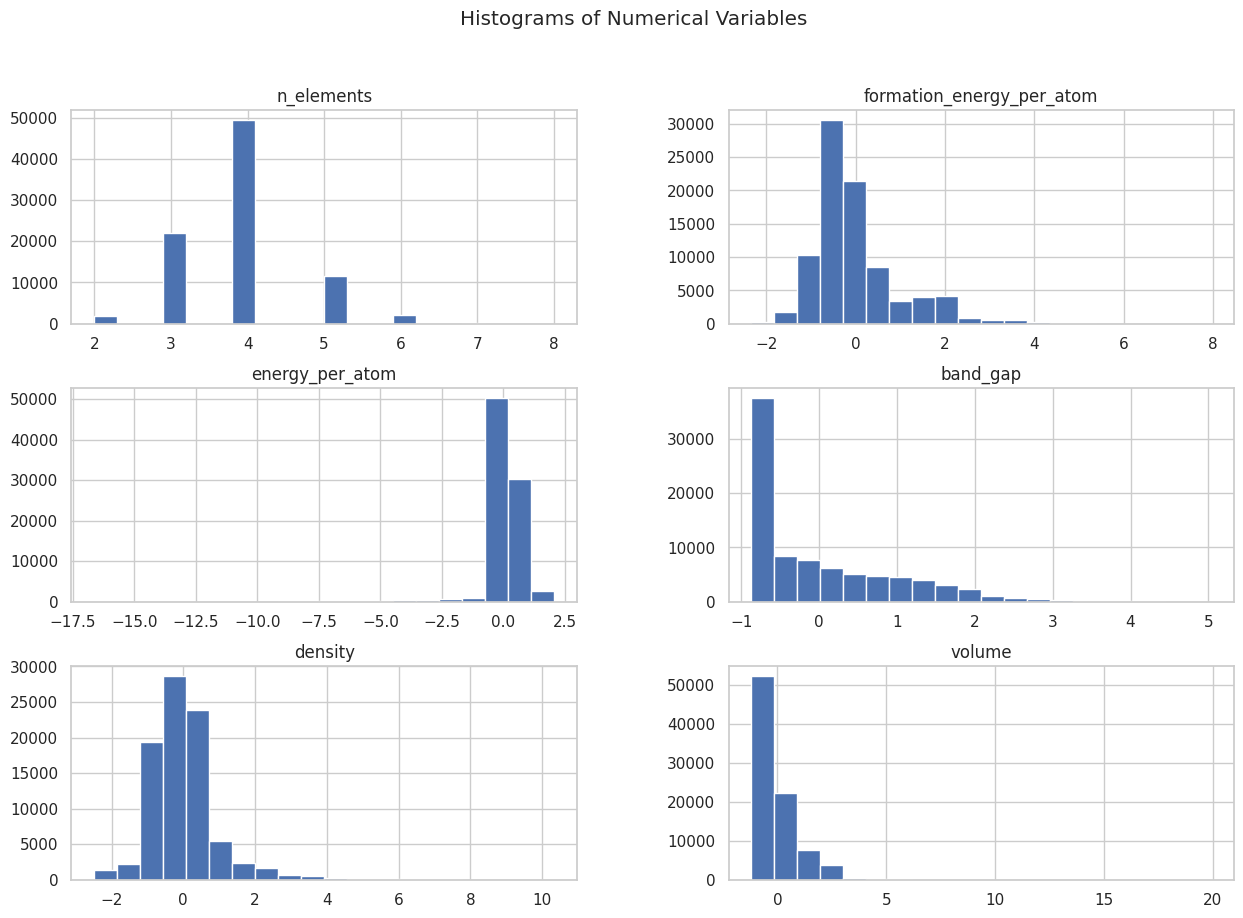

In [ ]:
df[num_cols].hist(figsize=(15,10), bins=20)
plt.suptitle("Histograms of Numerical Variables")
plt.show()


# Distribution of numerical variables — Interpretation

The histograms provide insight into the shape, spread, and asymmetry
of the numerical features across the dataset.


---


* **n_elements** :
>The distribution is discrete and concentrated, with a clear peak around 4 elements.
This confirms that most materials in the dataset have moderate compositional complexity,
while very simple or highly complex materials are less common.



* **formation_energy_per_atom**
>The distribution is centered near zero with a noticeable right tail.
This suggests that while many materials cluster around similar stability regimes,
a smaller subset exhibits significantly higher formation energies,
indicating less thermodynamically favorable structures.


* **energy_per_atom**
>The distribution is strongly left-skewed, with a long tail toward negative values.
This reflects the wide range of energetic environments across materials
and highlights the presence of deeply bound states.


* **band_gap**

> A large concentration of values appears near zero or below,
with a gradually decreasing tail toward higher values.
This confirms that metallic and low-gap materials dominate the dataset,
while wide-band-gap semiconductors are comparatively rare.



* density
> The distribution is approximately unimodal, centered near zero,
with moderate skewness and a few high-density outliers.
This indicates substantial but controlled variability in structural compactness.

* volume
 > The distribution is highly right-skewed,
showing that most materials occupy relatively small volumes,
while a limited number exhibit very large unit-cell volumes.

---
From an EDA standpoint, these histograms reveal:

strong asymmetry in several variables,

the presence of outliers,

and non-Gaussian behavior in key physical properties.

This reinforces the idea that visual exploration is essential
before applying statistical models or dimensionality reduction techniques.

*b-Boxplots (outlier detection)*

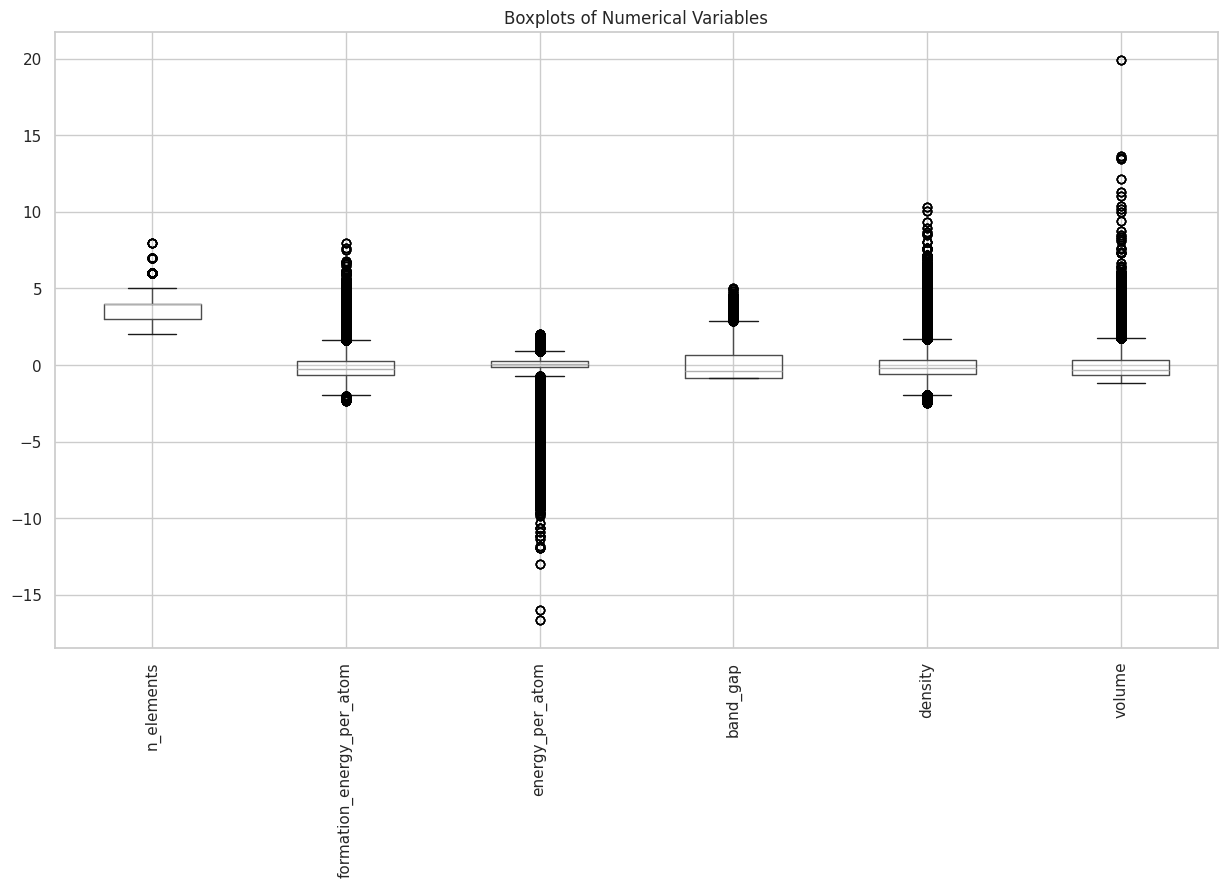

In [ ]:
plt.figure(figsize=(15,8))
df[num_cols].boxplot(rot=90)
plt.title("Boxplots of Numerical Variables")
plt.show()


# **7. Outlier detection using Z-score**

In [ ]:
from scipy import stats

z_scores = np.abs(stats.zscore(df[num_cols]))
outliers = (z_scores > 3).sum(axis=0)

outlier_table = pd.DataFrame({
    "Outliers Count": outliers
})

outlier_table[outlier_table["Outliers Count"] > 0]


,Outliers Count
0,72
1,1452
2,1860
3,864
4,1572
5,1036


# **Outlier detection — Boxplots and Z-score**

Boxplots provide a visual summary of dispersion and extreme values
across the numerical variables, while the Z-score method offers a quantitative criterion
to identify observations that deviate strongly from the mean.


---


> **Boxplot observations:**

* All continuous variables exhibit outliers, confirming the non-Gaussian nature
of materials data.

* energy_per_atom shows the most pronounced extreme values,
with a long negative tail corresponding to deeply bound structures.

* density and volume display several high-end outliers,
reflecting materials with unusually compact or expansive unit cells.

* formation_energy_per_atom and band_gap also contain scattered extremes,
indicating rare but physically meaningful regimes.

> **Z-score outlier counts:**
*The Z-score analysis confirms the boxplot observations:*

* Outliers are present but limited compared to the dataset size.

* No single variable dominates the anomaly structure.

* Extreme values represent a small fraction of the total population
and are distributed across different physical properties.

---
From a chemometric perspective, these outliers are not necessarily errors.
In materials science, extreme values often correspond to:

>unusual compositions,

>rare structural motifs,

> or physically interesting edge cases.

At this stage, EDA suggests that blind outlier removal would risk losing information.
Instead, outliers should be:

>retained and monitored,

>or treated with robust methods during modeling.

**This step reinforces a key principle of EDA:
understanding variability matters more than suppressing it.**

# **8. Bivariate analysis**

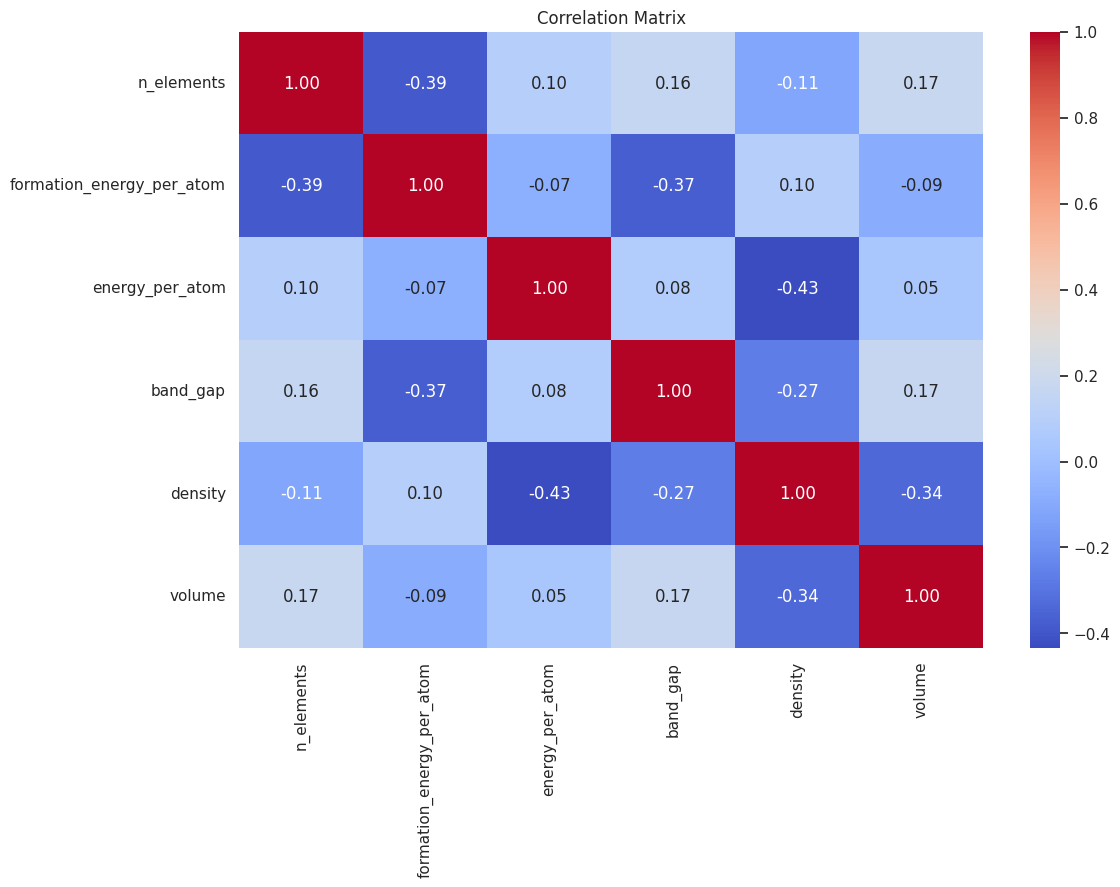

In [ ]:
corr = df[num_cols].corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()


# **Bivariate analysis — Correlation matrix**

The correlation matrix summarizes the linear relationships
between the numerical variables in the dataset.

Overall, most correlations are moderate to weak,
indicating limited redundancy and suggesting that each variable
captures a distinct aspect of material behavior.


---


> Key observations:

* n_elements vs formation_energy_per_atom (−0.39)
Materials with higher compositional complexity tend to exhibit
lower formation energies, suggesting a tendency toward
increased stability as the number of elements increases.


* formation_energy_per_atom vs band_gap (−0.37)
A moderate negative correlation indicates that more stable materials
are more likely to exhibit larger band gaps,
linking thermodynamic stability to electronic structure.

* energy_per_atom vs density (−0.43)
This is the strongest observed correlation.
Denser materials tend to have lower energy per atom,
reflecting tighter atomic packing and stronger bonding.

* band_gap vs density (−0.27)
A weak-to-moderate negative relationship suggests that
denser materials are more likely to be metallic or low-gap systems.

* density vs volume (−0.34)
As expected, materials with larger volumes
tend to have lower densities.

Other variable pairs show correlations close to zero,
indicating minimal linear dependence.

---

From an EDA perspective, this analysis shows that:

* no pair of variables is strongly collinear,

* multivariate methods are unlikely to suffer from severe multicollinearity,

* and physical trends are present but not dominant.

At this stage, EDA reveals a dataset with rich but balanced relationships,
where understanding emerges from combined patterns rather than single variables.

Exploratory Data Analysis is not about answering questions, but about learning how to ask them correctly. By examining structure, distributions, relationships, and outliers, the dataset becomes understandable rather than abstract. Its variability, scale, and rare behaviors are now visible, providing clarity and confidence for what comes next. With this foundation in place, the path is open to move from observation to representation, from patterns to relationships, and toward the next steps where materials meet chemometrics.